In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df_ppg = pd.read_excel(r"E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\PPG整体未格式对齐数据.xlsx",
                       header=None)
df_ppg

,0,1,2,3,4,5,6,7
0,PPG_SDNN_overall_delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000
2,1,-38.294326,-49.202148,-98.004498,-51.195793,-130.311765,-273.322191,-78.417727
3,2,-66.995662,-61.190510,-58.940228,1.730011,75.353476,71.017922,-15.862818
4,3,-14.004751,-17.764087,-10.366224,-39.455392,-52.742046,-59.073254,-26.510055
...,...,...,...,...,...,...,...,...
74,12,19.233971,8.533239,34.724970,8.318121,24.432758,11.556227,14.898081
75,13,17.061531,16.911011,6.236851,18.775332,6.357389,1.064786,7.234849
76,14,1.474222,7.283353,-2.687695,0.448222,-4.935690,0.994016,5.355099
77,15,-4.700414,-2.979002,-2.589163,-2.597226,-4.611496,2.521705,0.509648


In [3]:
def read_group_sheet(df, group_name):
    """
    从一个 sheet（如 A、B）中读取所有指标块
    """
    all_blocks = []
    i = 0
    while i < len(df):
        # 跳过空行
        if pd.isna(df.iloc[i, 0]):
            i += 1
            continue

        # 1️⃣ 指标名
        metric = str(df.iloc[i, 0]).strip()
        i += 1

        # 2️⃣ 第二行：组别与天数
        header_row = df.iloc[i].dropna().tolist()
        group = header_row[0]  # 比如 A
        days = header_row[1:]  # [1, 2, 3, 4, 5, 6, 7]
        i += 1

        # 3️⃣ 读取数据行（直到遇到空行）
        data_rows = []
        while i < len(df) and not all(pd.isna(df.iloc[i])):
            data_rows.append(df.iloc[i].tolist())
            i += 1

        # 4️⃣ 转为 DataFrame
        block_df = pd.DataFrame(data_rows, columns=["subject"] + days)
        block_df = block_df.melt(id_vars="subject", var_name="day", value_name="value")
        block_df["group"] = group
        block_df["metric"] = metric
        all_blocks.append(block_df)

    # 合并所有指标
    return pd.concat(all_blocks, ignore_index=True)


def read_hrv_excel(path):
    """
    从包含多个组（sheet）的 Excel 文件读取数据。
    每个 sheet 结构相同。
    """
    xls = pd.ExcelFile(path)
    all_groups = []

    for sheet in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet, header=None)
        group_df = read_group_sheet(df, sheet)
        all_groups.append(group_df)

    # 合并所有 sheet 的数据
    result = pd.concat(all_groups, ignore_index=True)
    return result[["metric", "group", "subject", "day", "value"]]


# 使用
file = "E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\PPG整体未格式对齐数据.xlsx"
df_final = read_hrv_excel(file)

df_final.sort_values(["metric", "group", "subject", "day"], inplace=True)
df_final.reset_index(drop=True, inplace=True)

df_final

,metric,group,subject,day,value
0,PPG_AMP_overall_delta,A,1,1.0,-416.901665
1,PPG_AMP_overall_delta,A,1,2.0,-180.838319
2,PPG_AMP_overall_delta,A,1,3.0,-38.509366
3,PPG_AMP_overall_delta,A,1,4.0,-150.264199
4,PPG_AMP_overall_delta,A,1,5.0,-490.561812
...,...,...,...,...,...
891,PPG_SDNN_overall_delta,B,16,3.0,-17.823901
892,PPG_SDNN_overall_delta,B,16,4.0,-25.445083
893,PPG_SDNN_overall_delta,B,16,5.0,-234.662136
894,PPG_SDNN_overall_delta,B,16,6.0,-8.391910


In [4]:
df_final.to_excel(r"E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\PPG整体数据格式对齐.xlsx", index=False)

In [5]:
df_final_statistical = df_final.groupby(["metric", "group", "day"])["value"].agg(["mean", "std", "count"]).reset_index()
df_final_statistical["sem"] = df_final_statistical["std"] / np.sqrt(df_final_statistical["count"])
# df_final_statistical.to_excel(r"E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\整体数据统计\ppg.xlsx",
#                               index=False)
df_final_statistical.columns
df_final_statistical.group = df_final_statistical.group.replace({"A": "Alcohol", "B": "Control"})

df_final_statistical

,metric,group,day,mean,std,count,sem
0,PPG_AMP_overall_delta,Alcohol,1.0,800.564729,708.257955,16,177.064489
1,PPG_AMP_overall_delta,Alcohol,2.0,1547.221643,1690.943485,16,422.735871
2,PPG_AMP_overall_delta,Alcohol,3.0,273.254429,2047.997231,16,511.999308
3,PPG_AMP_overall_delta,Alcohol,4.0,1589.023736,1798.209007,16,449.552252
4,PPG_AMP_overall_delta,Alcohol,5.0,345.028410,1849.946990,16,462.486748
5,PPG_AMP_overall_delta,Alcohol,6.0,1330.456691,1586.247837,16,396.561959
6,PPG_AMP_overall_delta,Alcohol,7.0,1883.347292,2551.171152,16,637.792788
7,PPG_AMP_overall_delta,Control,1.0,989.732908,3002.508800,16,750.627200
8,PPG_AMP_overall_delta,Control,2.0,1159.469574,3996.216710,16,999.054177
9,PPG_AMP_overall_delta,Control,3.0,696.643415,1645.637263,16,411.409316


In [6]:
tables = []

# 获取所有指标名
metrics_ppg = df_final_statistical['metric'].unique()

for m in metrics_ppg:
    # 取出该指标的数据
    df_m = df_final_statistical[df_final_statistical['metric'] == m]

    # 生成 “mean ± std” 字符串
    df_m['mean_std'] = (
            df_m['mean'].round(3).astype(str) + " ± " + df_m['std'].round(3).astype(str)
    )

    # pivot：行=group，列=day，值=mean±std
    table_m = df_m.pivot(index='group', columns='day', values='mean_std')

    # 在最左侧插入一列指标名称，用于输出时区分分块
    table_m.insert(0, 'metric', m)

    tables.append(table_m)

# 拼接成一个最终表
df_wide = pd.concat(tables, axis=0)

df_wide.to_excel(r"E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\整体数据统计\ppg.xlsx")
df_wide

day,metric,1.0,2.0,3.0,4.0,5.0,6.0,7.0
group,,,,,,,,
Alcohol,PPG_AMP_overall_delta,800.565 ± 708.258,1547.222 ± 1690.943,273.254 ± 2047.997,1589.024 ± 1798.209,345.028 ± 1849.947,1330.457 ± 1586.248,1883.347 ± 2551.171
Control,PPG_AMP_overall_delta,989.733 ± 3002.509,1159.47 ± 3996.217,696.643 ± 1645.637,1029.858 ± 1767.362,82.291 ± 2946.118,831.354 ± 1082.336,832.844 ± 2455.084
Alcohol,PPG_HR_overall_delta,7.147 ± 9.719,5.8 ± 10.928,8.209 ± 11.11,7.871 ± 11.323,6.739 ± 11.534,7.868 ± 15.861,6.149 ± 7.192
Control,PPG_HR_overall_delta,7.613 ± 9.39,6.62 ± 8.218,5.601 ± 10.815,5.907 ± 7.207,7.697 ± 10.913,3.23 ± 10.787,3.215 ± 7.931
Alcohol,PPG_RMSSD_overall_delta,-76.609 ± 48.274,-58.0 ± 48.672,-98.445 ± 100.331,-60.91 ± 61.944,-106.091 ± 94.153,-77.691 ± 94.263,-62.866 ± 57.119
Control,PPG_RMSSD_overall_delta,-106.324 ± 93.082,-109.87 ± 114.038,-51.568 ± 84.408,-72.468 ± 81.585,-81.856 ± 105.559,-54.615 ± 70.759,-25.462 ± 66.52
Alcohol,PPG_SDNN_overall_delta,-62.249 ± 36.783,-44.518 ± 27.846,-79.491 ± 73.677,-51.8 ± 46.292,-74.049 ± 68.969,-59.108 ± 86.049,-46.184 ± 46.438
Control,PPG_SDNN_overall_delta,-79.988 ± 67.705,-83.76 ± 83.793,-35.918 ± 66.404,-47.267 ± 59.694,-59.571 ± 77.177,-42.89 ± 57.703,-10.413 ± 49.022


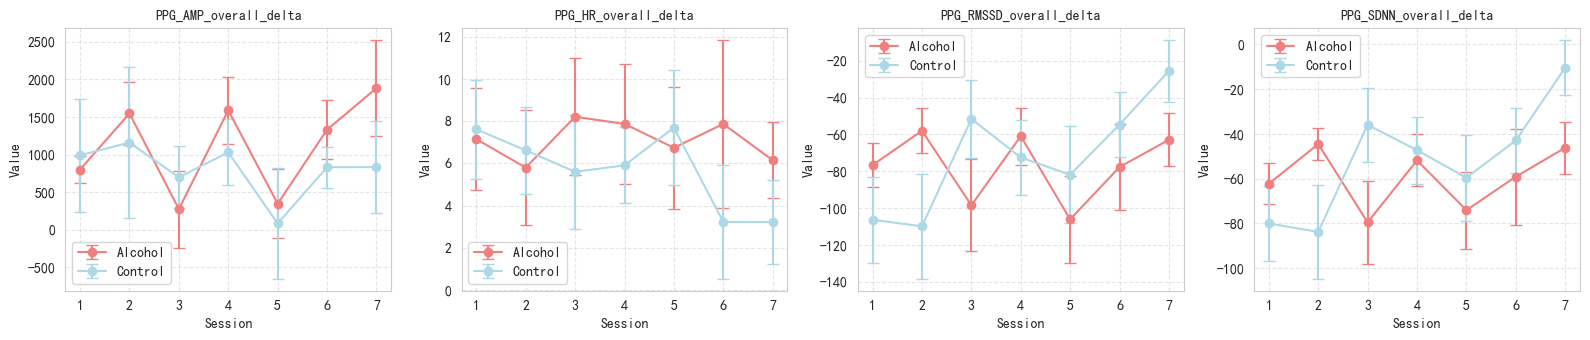

In [7]:
# 假设 df_final 已经存在并整理好
df_final["group"] = df_final["group"].replace({"A": "Alcohol", "B": "Control"})

# 计算均值与标准误
summary = (
    df_final.groupby(["metric", "group", "day"])["value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["sem"] = summary["std"] / np.sqrt(summary["count"])

# 获取所有指标
metrics = summary["metric"].unique()
n_metrics = len(metrics)

# 布局：每行4张图
ncols = 4
nrows = int(np.ceil(n_metrics / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 3.5 * nrows), sharey=False)

# 如果只有一行或一列，axes 需要转为数组方便索引
axes = np.array(axes).reshape(-1)

# 定义组别颜色
group_colors = {"Alcohol": "lightcoral", "Control": "lightblue"}

for i, metric in enumerate(metrics):
    ax = axes[i]
    data = summary[summary["metric"] == metric]

    # 画Alcohol、Control两组的折线图+误差棒
    for group, gdata in data.groupby("group"):
        ax.errorbar(
            gdata["day"],
            gdata["mean"],
            yerr=gdata["sem"],
            marker="o",
            capsize=4,
            label=f"{group}",
            color=group_colors.get(group, "black")  # 根据组别选择颜色
        )

    ax.set_title(metric, fontsize=10)
    ax.set_xlabel("Session")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

# 删除多余空子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

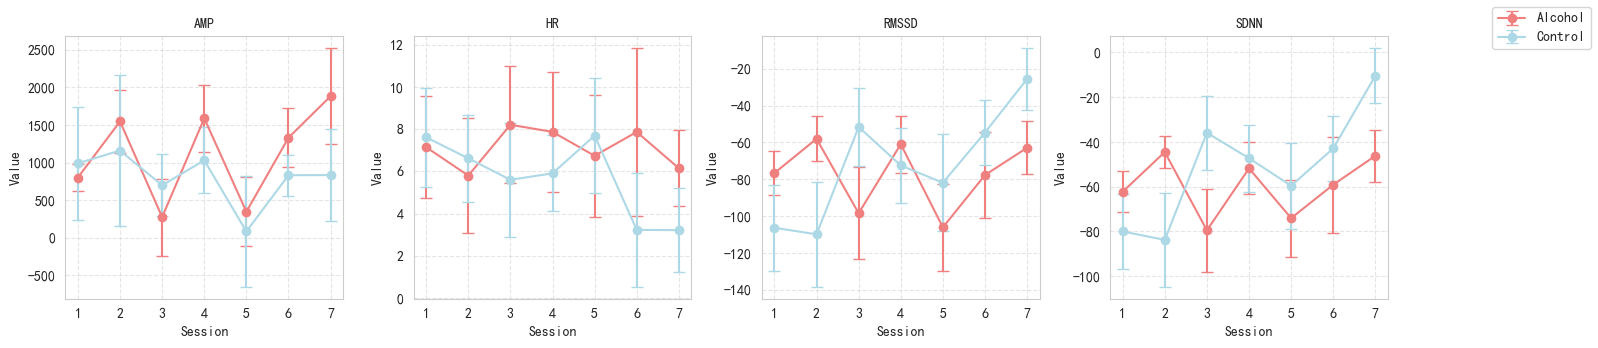

In [8]:
# 假设 df_final 已经存在并整理好
df_final["group"] = df_final["group"].replace({"A": "Alcohol", "B": "Control"})

# 计算均值与标准误
summary = (
    df_final.groupby(["metric", "group", "day"])["value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["sem"] = summary["std"] / np.sqrt(summary["count"])

# 获取所有指标
metrics = summary["metric"].unique()
n_metrics = len(metrics)

# ✅ 自定义标题列表（与 metrics 顺序一一对应）
# 例如：
titles = [
    'AMP',
    'HR',
    'RMSSD',
    'SDNN'
    # 如果有更多指标，请继续添加标题
]

# 布局：每行4张图
ncols = 4
nrows = int(np.ceil(n_metrics / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(4 * ncols, 3.5 * nrows),
    sharey=False
)
axes = np.array(axes).reshape(-1)

# 定义组别颜色
group_colors = {"Alcohol": "lightcoral", "Control": "lightblue"}

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i]
    data = summary[summary["metric"] == metric]

    # 画 Alcohol / Control 两组的折线图 + 误差棒
    for group, gdata in data.groupby("group"):
        ax.errorbar(
            gdata["day"],
            gdata["mean"],
            yerr=gdata["sem"],
            marker="o",
            capsize=4,
            label=f"{group}",
            color=group_colors.get(group, "black")
        )

    ax.set_xticks(range(1, 8))
    ax.set_xticklabels(range(1, 8))

    # ✅ 使用自定义标题
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Session")
    ax.set_ylabel("Value")
    ax.grid(True, linestyle="--", alpha=0.5)

# 删除多余空子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ✅ 从整个 figure 收集图例句柄（自动汇总所有子图的 label）
handles, labels = [], []
for ax in fig.axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:  # 避免重复
            handles.append(hh)
            labels.append(ll)

fig.legend(handles, labels, loc="upper right", frameon=True)
fig.tight_layout(rect=[0, 0, 0.88, 1])

plt.show()


In [9]:
summary["metric"].unique()

array(['PPG_AMP_overall_delta', 'PPG_HR_overall_delta',
       'PPG_RMSSD_overall_delta', 'PPG_SDNN_overall_delta'], dtype=object)

In [10]:
# 假设 Control 对应 Placebo
group_map = {
    "Alcohol": "Alcohol",
    "Control": "Placebo"
}

for metric in summary["metric"].unique():
    data = summary[summary["metric"] == metric]

    result = pd.DataFrame([
        data[data["group"] == "Alcohol"].sort_values("day")["mean"].values,
        data[data["group"] == "Control"].sort_values("day")["mean"].values,
        data[data["group"] == "Alcohol"].sort_values("day")["sem"].values,
        data[data["group"] == "Control"].sort_values("day")["sem"].values,
    ])

    print(f"\n===== {metric} =====")
    print(
        result
        .round(3)
        .to_csv(sep="\t", index=False, header=False)
    )



===== PPG_AMP_overall_delta =====
800.565	1547.222	273.254	1589.024	345.028	1330.457	1883.347
989.733	1159.47	696.643	1029.858	82.291	831.354	832.844
177.064	422.736	511.999	449.552	462.487	396.562	637.793
750.627	999.054	411.409	441.841	736.53	270.584	613.771


===== PPG_HR_overall_delta =====
7.147	5.8	8.209	7.871	6.739	7.868	6.149
7.613	6.62	5.601	5.907	7.697	3.23	3.215
2.43	2.732	2.777	2.831	2.884	3.965	1.798
2.348	2.055	2.704	1.802	2.728	2.697	1.983


===== PPG_RMSSD_overall_delta =====
-76.609	-58.0	-98.445	-60.91	-106.091	-77.691	-62.866
-106.324	-109.87	-51.568	-72.468	-81.856	-54.615	-25.462
12.069	12.168	25.083	15.486	23.538	23.566	14.28
23.27	28.509	21.102	20.396	26.39	17.69	16.63


===== PPG_SDNN_overall_delta =====
-62.249	-44.518	-79.491	-51.8	-74.049	-59.108	-46.184
-79.988	-83.76	-35.918	-47.267	-59.571	-42.89	-10.413
9.196	6.961	18.419	11.573	17.242	21.512	11.61
16.926	20.948	16.601	14.924	19.294	14.426	12.256

